In [7]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy

In [8]:
# Load data from /asset
import os

# Get list of CSV files in asset directory
asset_dir = './asset'
csv_files = [f for f in os.listdir(asset_dir) if f.endswith('.csv')]
print(f"Found {len(csv_files)} CSV files: {csv_files}")

# Load all datasets
data_files = {}
for file in csv_files:
    file_path = os.path.join(asset_dir, file)
    data_files[file.replace('.csv', '')] = pd.read_csv(file_path)
    print(f"Loaded {file}: shape {data_files[file.replace('.csv', '')].shape}")


Found 4 CSV files: ['personalfinance_2020_final.csv', 'finanzen_2025_final.csv', 'personalfinance_2025_final.csv', 'finanzen_2020_final.csv']
Loaded personalfinance_2020_final.csv: shape (103192, 11)
Loaded finanzen_2025_final.csv: shape (22669, 11)
Loaded personalfinance_2025_final.csv: shape (72726, 11)
Loaded finanzen_2020_final.csv: shape (4654, 11)


In [9]:
# Explore data structure
for name, df in data_files.items():
    print(f"\n{'='*50}")
    print(f"Dataset: {name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nFirst few rows:")
    print(df.head())
    print(f"\nData types:\n{df.dtypes}")
    print(f"\nMissing values:\n{df.isnull().sum()}")



Dataset: personalfinance_2020_final
Shape: (103192, 11)

Columns: ['author_fullname', 'created_utc', 'id', 'selftext', 'title', 'url', 'full_text', 'detected_language', 'language_confidence', 'text_for_sentiment', 'text_for_keywords']

First few rows:
  author_fullname  created_utc      id  \
0     t2_5ccxoo7l   1577836895  eib0o9   
1        t2_o24ok   1577836915  eib0tz   
2     t2_38bz0erk   1577837590  eib64c   
3        t2_ydgta   1577838393  eibc3a   
4        t2_8yc8c   1577838434  eibcfz   

                                            selftext  \
0  I've lived in the same apartment for over 4 ye...   
1  My wife and I have three credit cards from the...   
2  Background: I'm 30 y/o, I have a stable job wi...   
3  I'm 18 years old and this summer I've worked j...   
4  I work for a US based company that provided RS...   

                                               title  \
0  In apartment while house is being finished and...   
1  Does closing hardly used credit cards impa

In [10]:
# NER via SpaCy
try:
    nlp = spacy.load("en_core_web_lg")
except OSError:
    print("Downloading spaCy model...")
    os.system("python -m spacy download en_core_web_lg")
    nlp = spacy.load("en_core_web_lg")

# Function to extract entities
def extract_entities(text):
    if pd.isna(text):
        return []
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

# Example: Extract entities from first dataset
print("Sample NER Results:")
print("="*60)

# Assuming there's a text column (adjust column name as needed)
for name, df in data_files.items():
    if len(df) > 0:
        # Find text column (commonly named 'text', 'title', 'content', etc.)
        text_cols = [col for col in df.columns if 'text' in col.lower() or 'content' in col.lower() or 'title' in col.lower()]
        if text_cols:
            text_col = text_cols[0]
            print(f"\n{name} - Processing '{text_col}' column:")
            sample_text = df[text_col].iloc[0]
            entities = extract_entities(sample_text)
            print(f"Text: {sample_text[:100]}...")
            print(f"Entities: {entities}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 6.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')



[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Sample NER Results:

personalfinance_2020_final - Processing 'selftext' column:
Text: I've lived in the same apartment for over 4 years and I absolutely love it. They've always had an am...
Entities: [('over 4 years', 'DATE'), ('last year', 'DATE'), ('the end of February', 'DATE'), ('3 month', 'DATE'), ('Nov.', 'DATE'), ('3-5 month', 'DATE'), ('$150 extra', 'MONEY'), ('3 months', 'DATE'), ('the end of Jan date', 'DATE'), ('Yesterday', 'DATE'), ('about 60 days', 'DATE'), ('3/25/20', 'CARDINAL'), ('2 months', 'DATE'), ('first', 'ORDINAL'), ('60 days', 'DATE'), ('3 more months', 'DATE'), ('200', 'MONEY'), ('month to month', 'DATE'), ('350', 'MONEY'), ('each month', 'DATE'), ('Apr (2 months', 'DATE'), ('the 3 month', 'DATE'), ('Apr', 'ORG'), ('3-5 months', 'DATE'), ('Thursday', 'DATE'), ("New Year's", 'EVENT'), ('550', 'MONEY'), ('each month', 'DATE'), ('1 to 2 months', 'DATE'), ('2 months', 'DATE')]

finanzen_2025_final - Processing 'selftext' column:
Text: Jedes Jahr das gleiche. Schon v

Entity Type Distribution:
{'DATE': 620, 'MONEY': 478, 'CARDINAL': 580, 'ORDINAL': 51, 'ORG': 1549, 'EVENT': 16, 'PERSON': 2712, 'GPE': 529, 'TIME': 27, 'QUANTITY': 26, 'WORK_OF_ART': 18, 'PERCENT': 222, 'PRODUCT': 79, 'NORP': 85, 'LOC': 28, 'FAC': 60, 'LANGUAGE': 2, 'LAW': 8}


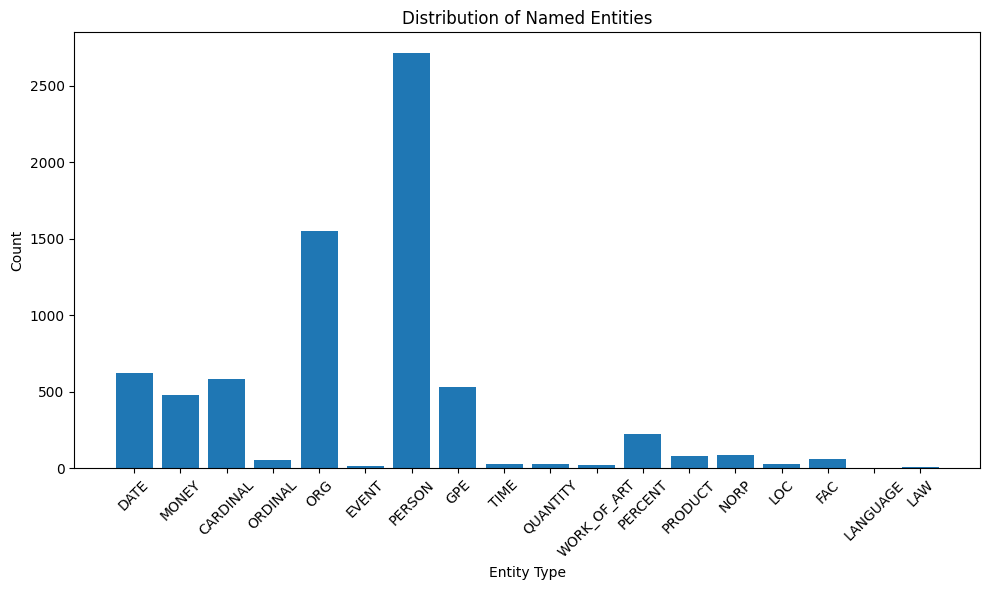

In [11]:
# Analyze entity distribution
all_entities = []
for name, df in data_files.items():
    text_cols = [col for col in df.columns if 'text' in col.lower() or 'content' in col.lower()]
    if text_cols:
        text_col = text_cols[0]
        for text in df[text_col].dropna().head(100):  # Sample first 100 texts
            entities = extract_entities(text)
            all_entities.extend(entities)

# Count entity types
if all_entities:
    entity_types = {}
    for text, label in all_entities:
        entity_types[label] = entity_types.get(label, 0) + 1
    
    print("Entity Type Distribution:")
    print(entity_types)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(entity_types.keys(), entity_types.values())
    ax.set_xlabel('Entity Type')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Named Entities')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
